In [11]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cdft.dft1d import dft_core

torch.set_default_dtype(torch.float64)
device = torch.device('cpu')

pi = np.pi
kB = 1.380649e-23
NA = 6.02214076e23

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [12]:
sigma_ff = 1.0
epsilon_ff = 1.0
parameters = {'sigma': sigma_ff, 'epsilon': epsilon_ff}

T = 1.2
bulk_density = torch.tensor([0.5925])

In [13]:
H = 7.5
pad = 4.0
dz = 0.02

system_size = H+2.0*pad
points = int(round(system_size/dz))
cell_size = system_size/points
kin = int(round(pad/cell_size))
kout = points-kin

In [14]:
epsilonw = 2*np.pi*epsilon_ff
Delta = sigma_ff/np.sqrt(2.0)
sigmaw = sigma_ff

def steele(z, sigma, epsilon):
    
    return epsilon*(0.4*(sigma/z)**10-(sigma/z)**4-sigma**4/(3*Delta*(z+0.61*Delta)**3))

dft = dft_core(parameters, T, system_size, points, device)

Vext = torch.zeros_like(dft.z)
Vext[0:kin] = np.inf
Vext[kout:] = np.inf
zp = dft.z[kin:kout]-pad
Vext[kin:kout] = steele(zp, sigmaw, epsilonw)+steele(H-zp, sigmaw, epsilonw)

dft.initial_condition(bulk_density, Vext, potential_cutoff=50.)

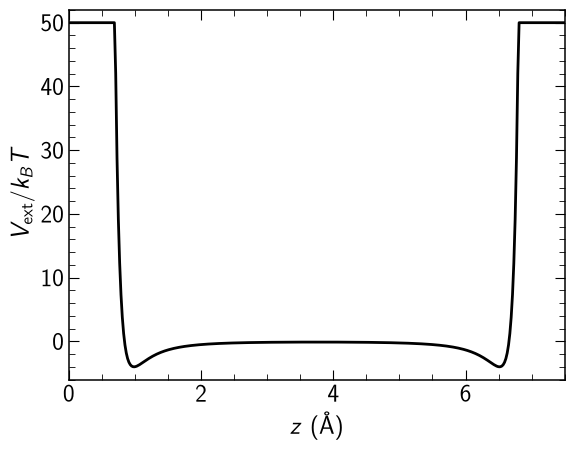

In [15]:
plt.plot(dft.z.cpu()-pad, dft.Vext.cpu(), color='k', lw=2.0)
plt.xlabel(r'$z$ (\AA{})', fontsize=18)
plt.ylabel(r'$V_{\mathsf{ext}}/k_BT$', fontsize=18)
plt.xlim(0.0, H)
plt.ylim(-6.0, 52.0)
plt.minorticks_on()
plt.tick_params(direction='in', right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in', which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in', which='major', length=7, bottom=True, top=True, left=True, right=True)

In [16]:
dft.equilibrium_density_profile(bulk_density, fmt='WB', solver='anderson',
                                anderson_damping=0.01, anderson_mmax=5, tol=1e-8)
print(dft.it, dft.error, dft.Omega)

962 tensor(9.8178e-09) tensor(-3.6759)


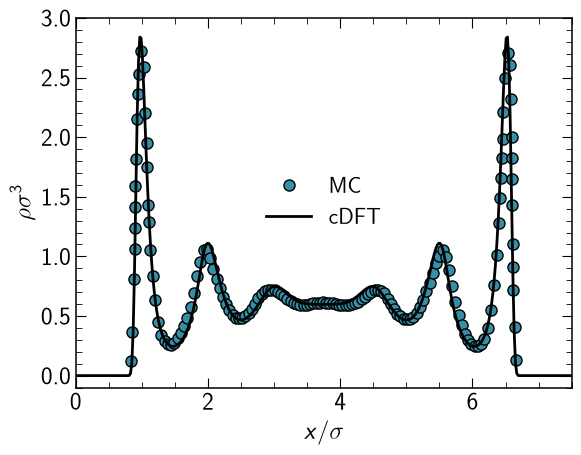

In [17]:
mc = np.loadtxt('data/lj-slitpore-steele-T1.2-rhob0.5925-H7.5-GEMC.dat')

plt.plot(mc[:,0], mc[:,1], 'o', color=colors[3], mew=1.0, ms=8, mec='k',label='MC')
plt.plot(dft.z-pad, dft.rho, color='k', lw=2.0, label='cDFT')
plt.xlabel(r'$x/ \sigma$', fontsize=18)
plt.ylabel(r'$\rho \sigma^3$', fontsize=18)
plt.xlim((0,H))
plt.ylim((-0.1,3.0))
plt.legend(fontsize=14)
plt.minorticks_on()
plt.tick_params(direction='in', right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in', which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in', which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k', loc='center')

calculando o diagrama de fases...
80 pontos -> lj_vle_thol.csv

desvio vs equacoes auxiliares (Tab. 7 do artigo):
  rho_v: max 0.30 %   rho_l: max 0.09 %   p: max 0.07 %
  (a incerteza declarada das proprias auxiliares e 1.8 %% em p e rho_v)

rho_c por diametro retilineo: 0.3114   (EOS usa 0.3100)

em unidades de metano (sigma=3.73 A, eps=148 K):
       T_K    rho_v    rho_l         p_Pa
103.600000 0.000038 0.016238 5.382016e+04
149.311392 0.000601 0.013430 1.039356e+06
193.880000 0.004174 0.007854 4.913926e+06


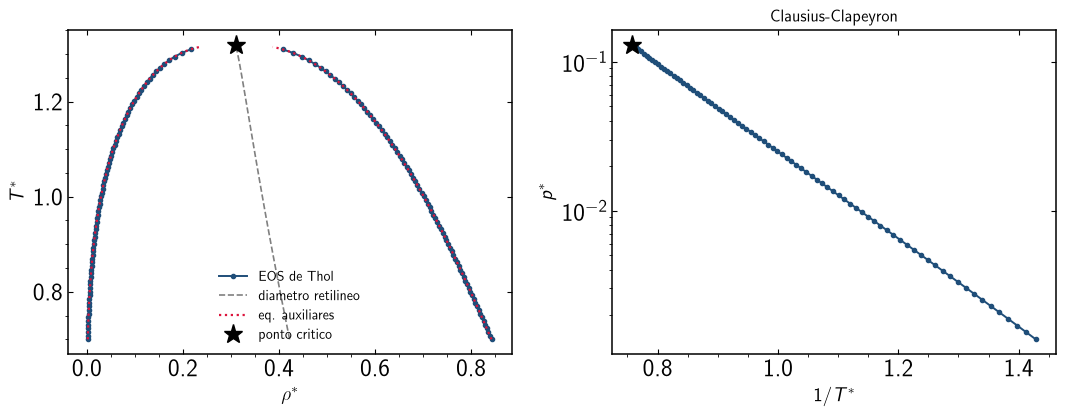

In [ ]:
import numpy as np
import torch
import pandas as pd
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

from cdft.lj_eos_thol import lj_eos, TC_STAR, RHOC_STAR

torch.set_default_dtype(torch.float64)

PC_STAR = 0.13006          # calculado da propria EOS em (Tc, rho_c)

# =====================================================================
# Trabalhar em unidades REDUZIDAS: com sigma = 1 e epsilon = 1, o rho
# que a classe recebe ja e rho* e a temperatura ja e T*. Nenhuma
# conversao para SI entra no caminho, o que evita o fator 1e30 do
# metodo pressure().
# =====================================================================

PARAMETERS = {'sigma': 1.0, 'epsilon': 1.0}


def props(eos, T, rho):
    """Devolve (p*, mu*/T*) num unico forward+backward.

        Z      = 1 + A01,           A01 = rho d(alpha^r)/d(rho)
        p*     = rho* T* Z
        mu*/T* = ln rho* + alpha^r + A01

    Chamo helmholtz_energy direto em vez de compressibility_factor/
    chemical_potential para nao pagar dois grafos e para nao mexer no
    requires_grad de tensores de fora.
    """
    r = torch.tensor([float(rho)], requires_grad=True)
    a = eos.helmholtz_energy(r)
    da = torch.autograd.grad(a, r)[0]
    A01 = float(r.detach()*da)
    ar = float(a.detach())
    return float(rho)*T*(1.0+A01), np.log(float(rho))+ar+A01


# =====================================================================
# Equacoes auxiliares, Tabela 7 do artigo. Servem para duas coisas:
# chute inicial (sem elas o Newton nao acha as duas raizes) e aferição
# do resultado.
# =====================================================================

_PV = ([-0.54000e+1, 0.44704e+0, -0.18530e+1, 0.19890e+0, -0.11250e+1],
       [1.00, 1.50, 4.70, 2.50, 21.4])
_RL = ([0.1362e+1, 0.2093e+1, -0.2110e+1, 0.3290e+0, 0.1410e+1],
       [0.313, 0.940, 1.630, 17.00, 2.400])
_RV = ([-0.69655e+1, -0.10331e+3, -0.20325e+1, -0.44481e+2, -0.18463e+2, -0.26070e+3],
       [1.320, 19.24, 0.360, 8.780, 4.040, 41.60])


def anc_pv(T):
    th = 1.0-T/TC_STAR
    return PC_STAR*np.exp((TC_STAR/T)*sum(ni*th**ti for ni, ti in zip(*_PV)))


def anc_rho_liq(T):
    th = 1.0-T/TC_STAR
    return RHOC_STAR*(1.0+sum(ni*th**ti for ni, ti in zip(*_RL)))


def anc_rho_vap(T):
    th = 1.0-T/TC_STAR
    return RHOC_STAR*np.exp(sum(ni*th**ti for ni, ti in zip(*_RV)))


# =====================================================================
# ELV: p(rho_v) = p(rho_l)  e  mu(rho_v) = mu(rho_l)
#
# Resolvido em log(rho) para manter positividade. Duas equacoes, duas
# incognitas -- nao uso substituicao sucessiva por coeficiente de
# fugacidade (o vapor_pressure da classe) porque ela fica lenta e
# instavel perto do critico.
# =====================================================================

def vle_point(T, rho_v0=None, rho_l0=None):
    eos = lj_eos(PARAMETERS, T)
    if rho_v0 is None:
        rho_v0, rho_l0 = anc_rho_vap(T), anc_rho_liq(T)

    def eqs(x):
        rv, rl = np.exp(x)
        pv, muv = props(eos, T, rv)
        pl, mul = props(eos, T, rl)
        return [pv-pl, muv-mul]

    x, _, ier, msg = fsolve(eqs, np.log([rho_v0, rho_l0]),
                            full_output=True, xtol=1e-12)
    rv, rl = np.exp(x)
    p, _ = props(eos, T, rv)
    # raizes coincidentes = falhou (achou o mesmo ramo duas vezes)
    ok = (ier == 1) and (rl/rv > 1.05)
    return rv, rl, p, ok, msg


def phase_diagram(T_min=0.70, T_max=1.31, n=80):
    """Varre de T_max para baixo: a continuacao de uma T para a proxima
    e mais estavel que partir das auxiliares em cada ponto, e perto do
    critico e onde o chute importa mais."""
    Ts = np.linspace(T_min, T_max, n)[::-1]
    rows = []
    rv0 = rl0 = None
    for T in Ts:
        rv, rl, p, ok, msg = vle_point(T, rv0, rl0)
        if not ok:                      # tenta de novo com as auxiliares
            rv, rl, p, ok, msg = vle_point(T)
        if ok:
            rows.append((T, rv, rl, p))
            rv0, rl0 = rv, rl
        else:
            print("  T*=%.4f nao convergiu (%s)" % (T, msg.strip()[:60]))
    # a coluna NAO pode se chamar 'T': df.T e a transposta do DataFrame,
    # e o acesso por atributo nunca chegaria na coluna
    df = pd.DataFrame(rows[::-1], columns=['Tstar', 'rho_v', 'rho_l', 'p'])
    df['rho_mean'] = 0.5*(df.rho_v+df.rho_l)
    return df


def critical_from_rectilinear(df, T_lo=1.0, T_hi=1.30):
    """Diametro retilineo + lei de escala, so para conferir que a
    extrapolacao reproduz o (Tc, rho_c) usado na propria EOS."""
    m = (df.Tstar >= T_lo) & (df.Tstar <= T_hi)
    A, B = np.polyfit(df.Tstar[m], df.rho_mean[m], 1)          # rho_med = A T + B
    # (rho_l - rho_v) = C (1 - T/Tc)^beta, beta = 0.325
    beta = 0.325
    x = (1.0-df.Tstar[m]/TC_STAR)**beta
    C = np.polyfit(x, (df.rho_l-df.rho_v)[m], 1)[0]
    return A*TC_STAR+B, C


if __name__ == '__main__':

    print("calculando o diagrama de fases...")
    df = phase_diagram(0.70, 1.31, 80)
    df.to_csv('lj_vle_thol.csv', index=False)
    print("%d pontos -> lj_vle_thol.csv\n" % len(df))

    # ---- aferição contra as equacoes auxiliares do artigo ----
    dv = 100*(df.rho_v/df.Tstar.map(anc_rho_vap)-1)
    dl = 100*(df.rho_l/df.Tstar.map(anc_rho_liq)-1)
    dp = 100*(df.p/df.Tstar.map(anc_pv)-1)
    print("desvio vs equacoes auxiliares (Tab. 7 do artigo):")
    print("  rho_v: max %.2f %%   rho_l: max %.2f %%   p: max %.2f %%"
          % (dv.abs().max(), dl.abs().max(), dp.abs().max()))
    print("  (a incerteza declarada das proprias auxiliares e 1.8 %% em p e rho_v)")

    rho_c_fit, _ = critical_from_rectilinear(df)
    print("\nrho_c por diametro retilineo: %.4f   (EOS usa %.4f)"
          % (rho_c_fit, RHOC_STAR))

    # ---- graficos ----
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

    ax[0].plot(df.rho_v, df.Tstar, 'o-', color="#234c73", ms=3, lw=1.4, label='EOS de Thol')
    ax[0].plot(df.rho_l, df.Tstar, 'o-', color='#1f4e79', ms=3, lw=1.4)
    ax[0].plot(df.rho_mean, df.Tstar, '--', color='0.5', lw=1.2, label='diametro retilineo')
    Tf = np.linspace(0.70, 1.315, 300)
    ax[0].plot([anc_rho_vap(x) for x in Tf], Tf, ':', color='crimson', lw=1.6,
               label='eq. auxiliares')
    ax[0].plot([anc_rho_liq(x) for x in Tf], Tf, ':', color='crimson', lw=1.6)
    ax[0].plot(RHOC_STAR, TC_STAR, '*', color='k', ms=14, label='ponto critico')
    ax[0].set_xlabel(r'$\rho^*$', fontsize=14)
    ax[0].set_ylabel(r'$T^*$', fontsize=14)
    ax[0].legend(fontsize=10, frameon=False)

    ax[1].semilogy(1.0/df.Tstar, df.p, 'o-', color='#1f4e79', ms=3, lw=1.4)
    ax[1].semilogy(1.0/TC_STAR, PC_STAR, '*', color='k', ms=14)
    ax[1].set_xlabel(r'$1/T^*$', fontsize=14)
    ax[1].set_ylabel(r'$p^*$', fontsize=14)
    ax[1].set_title('Clausius-Clapeyron', fontsize=12)

    for a in ax:
        a.minorticks_on()
        a.tick_params(direction='in', right=True, top=True)
    plt.tight_layout()
    plt.savefig('lj_vle_thol.png', dpi=150)

    # ---- conversao para unidades reais, se quiser ----
    def to_real(df, sigma, epsilon, M=None):
        """sigma em A, epsilon em K. Devolve T em K, rho em A^-3, p em Pa."""
        kB = 1.380649e-23
        out = pd.DataFrame({'T_K': df.Tstar*epsilon,
                            'rho_v': df.rho_v/sigma**3,
                            'rho_l': df.rho_l/sigma**3,
                            'p_Pa': df.p*epsilon*kB/(sigma*1e-10)**3})
        return out

    real = to_real(df, sigma=3.73, epsilon=148.0)     # metano
    real.to_csv('lj_vle_thol_metano.csv', index=False)
    print("\nem unidades de metano (sigma=3.73 A, eps=148 K):")
    print(real.iloc[[0, len(real)//2, -1]].to_string(index=False))